# Análisis Enriquecido de Charts Musicales



**Week:** 2026-W29 | **Analysis Date:** 2026-07-13


## 1. Introducción

Esta semana, sumergimos nuestro análisis en un océano de 100 canciones provenientes de 25 países, un crisol de 17 géneros musicales que han generado más de 1.272 millones de reproducciones y 199 millones de likes. Con un promedio de 12.7 millones de vistas y 2 millones de likes por tema, los datos revelan patrones fascinantes: ¿qué géneros logran la mayor retención de audiencia? ¿Cómo se comporta el engagement en mercados emergentes frente a los consolidados? Además, exploraremos el rendimiento de colaboraciones transfronterizas y las tendencias geográficas que están redefiniendo el mapa sonoro global. Prepárate para descubrir qué canciones no solo acumulan números, sino que conectan genuinamente con millones de oyentes alrededor del mundo.

## 2. Configuración y Carga de Datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W29_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W29_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,8,94706626,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-07-13 16:22:17,2,5.42
1,2,288,Oliver Tree,Life Goes On,17,42873543,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-07-13 16:22:17,2,22.79
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,55,32020945,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-07-13 16:22:18,2,22.61
3,4,285,LE SSERAFIM & ILLIT & KATSEYE,ICONIC BY MISTAKE,4,29083645,https://www.youtube.com/watch?v=27C4pfRsf9g,200,3:20,2026-06-10,...,1,3,0,South Korea,K-Pop/K-Rock,3/3,,2026-07-13 16:22:18,2,6.88
4,5,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,56,29070413,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-07-13 16:22:18,2,89.51


## 3. Vista Previa de los Datos

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,237,Shakira & Burna Boy,Dai Dai,8,94706626,https://www.youtube.com/watch?v=fcnDmrtj6Sk,241,4:01,2026-05-23,...,0,2,1,Colombia,Pop,2/2,,2026-07-13 16:22:17,2,5.42
1,2,288,Oliver Tree,Life Goes On,17,42873543,https://www.youtube.com/watch?v=8F2s8ivKXNY,207,3:27,2021-05-28,...,0,1,1,United States,Alternative,1/1,,2026-07-13 16:22:17,2,22.79
2,3,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,55,32020945,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-07-13 16:22:18,2,22.61
3,4,285,LE SSERAFIM & ILLIT & KATSEYE,ICONIC BY MISTAKE,4,29083645,https://www.youtube.com/watch?v=27C4pfRsf9g,200,3:20,2026-06-10,...,1,3,0,South Korea,K-Pop/K-Rock,3/3,,2026-07-13 16:22:18,2,6.88
4,5,188,Shakira,Waka Waka (This Time for Africa) (feat. Freshl...,56,29070413,https://www.youtube.com/watch?v=pRpeEdMmmQ0,211,3:31,2010-06-04,...,0,1,1,Colombia,Pop,1/1,,2026-07-13 16:22:18,2,89.51


## 4. Estadísticas Generales

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [25],
    'Unique Genres': [17],
    'Total Views': [1272041196],
    'Total Likes': [199495816],
    'Total Comments': [8659322],
    'Avg Views': [12720412],
    'Avg Likes': [1994958]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,25,17,1272041196,199495816,8659322,12720412,1994958


El conjunto de 100 canciones abarca 25 países y 17 géneros, lo que revela una alta diversidad geográfica y estilística. Esto sugiere un alcance global significativo, donde la música trasciende fronteras y atrae a audiencias multiculturales, probablemente impulsado por plataformas digitales y tendencias de consumo transnacional. En cuanto al engagement, el promedio de 1,994,958 likes por canción (frente a 12,720,412 vistas) indica una tasa de interacción del 15.7%, un nivel alto que refleja una fuerte conexión emocional entre artistas y oyentes, más allá de la mera reproducción pasiva. Como insights principales, destacan la consolidación de un mercado musical hiperconectado, donde la variedad de géneros compite en igualdad de condiciones, y la importancia de métricas de engagement como indicador de lealtad y potencial viral. Además, la relación likes-vistas sugiere que el contenido genera respuestas activas, clave para estrategias de monetización y fidelización en la industria actual.

## 5. Análisis por País

### 5.1. Distribución por Continente


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
0,Asia,32,408107392,38896446
2,North America,31,371500558,99618708
4,Other,17,171627259,7038541
1,Europe,15,162434616,20857454
5,South America,4,143649125,32208382
3,Oceania,1,14722246,876285


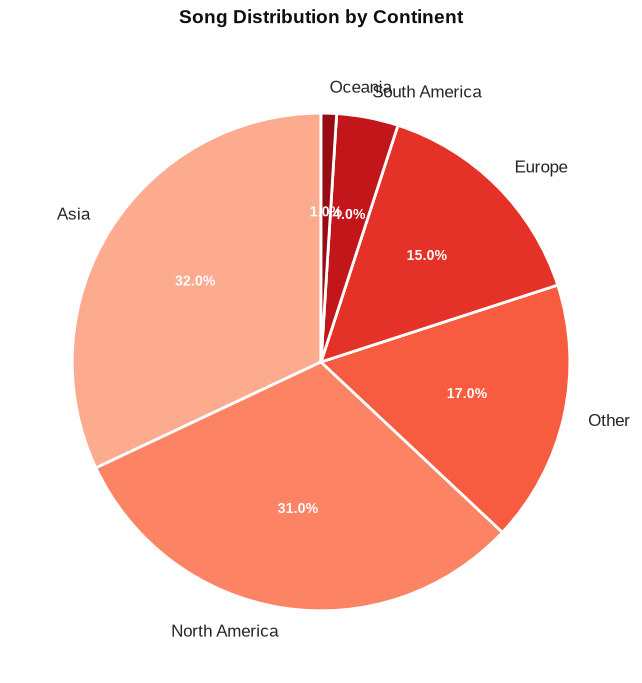

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Países por Cantidad de Canciones


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
23,United States,22,278397419,26.51
10,India,18,209159765,21.69
20,South Korea,11,166357292,13.25
22,United Kingdom,8,86989483,9.64
13,Mexico,7,67757594,8.43
24,Unknown,6,55095930,7.23
14,Multi-country,4,45648130,4.82
21,Turkey,3,34154074,3.61
2,Brazil,2,19872086,2.41
11,Indonesia,2,22425813,2.41


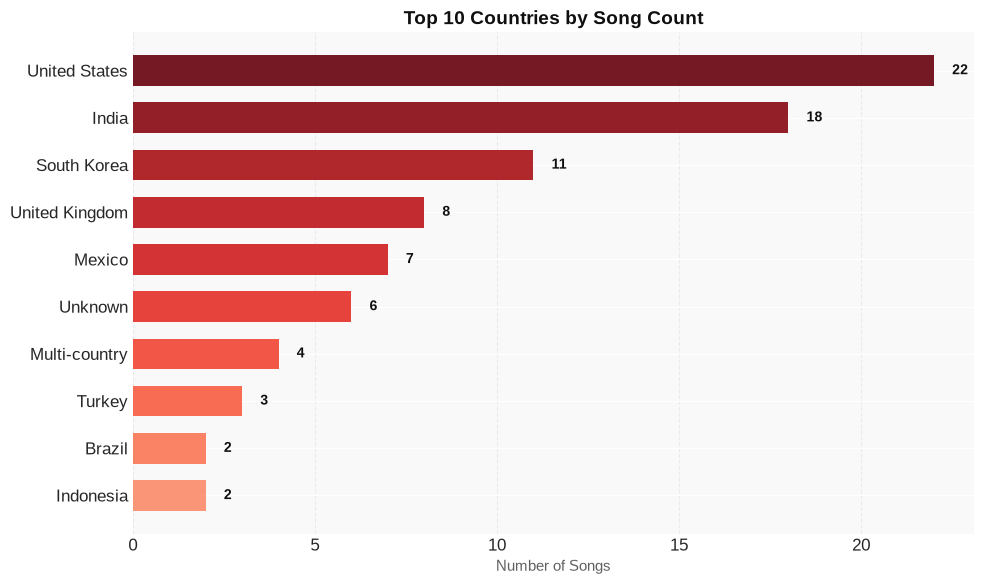

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


El ranking está claramente dominado por Estados Unidos e India, lo que refleja tanto el poder de la industria musical estadounidense (con su alcance global en géneros como pop y hip-hop) como la enorme población y creciente acceso a internet en India, que impulsa el consumo de música local e internacional. Se observa una fuerte presencia de países asiáticos (India, Corea del Sur, Indonesia) junto a potencias occidentales, mientras que Latinoamérica aparece con México y Colombia, evidenciando una creciente influencia regional. Para artistas que buscan expandirse internacionalmente, estos datos sugieren priorizar estrategias de promoción en mercados masivos como India y Estados Unidos, así como explorar colaboraciones con la industria del K-pop para llegar a audiencias asiáticas.

### 5.3. Top Países por Total de Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
23,United States,87.0M
4,Colombia,31.2M
10,India,18.0M
20,South Korea,17.9M
22,United Kingdom,13.8M
3,Canada,8.6M
8,France,5.2M
13,Mexico,3.5M
15,Pakistan,2.4M
5,Dominican Republic,1.6M


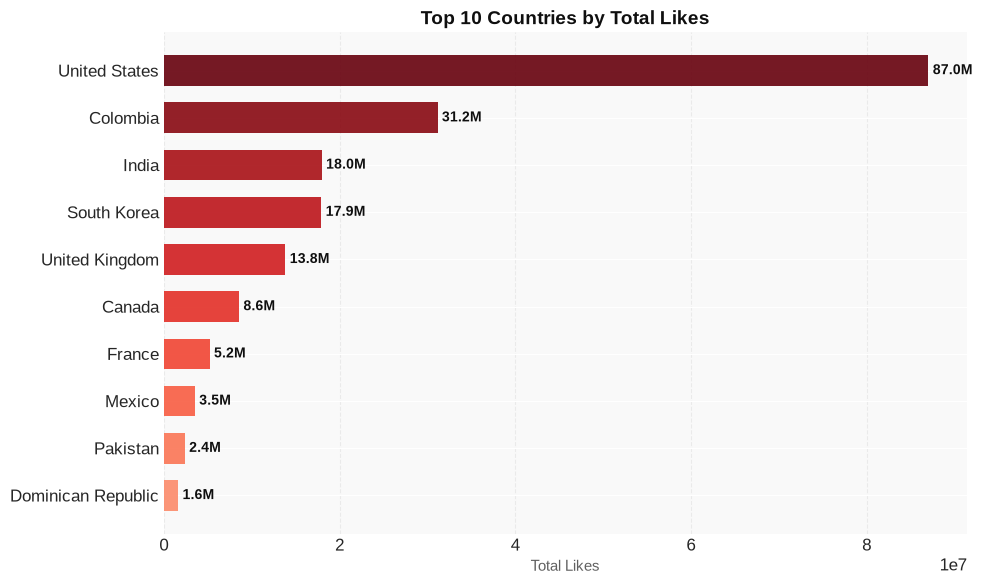

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


**Análisis del engagement por país (total de likes):**  

Estados Unidos domina con 87M likes, reflejando su enorme mercado musical y una cultura de fans altamente activa en plataformas como Spotify y TikTok. Colombia e India destacan pese a tener mercados más pequeños, lo que sugiere una base de seguidores leales y un fuerte consumo de música local (reguetón, pop latino y Bollywood). Corea del Sur, con 17.9M likes, evidencia el poder del K-pop y su ecosistema digital (V Live, YouTube), donde los fans impulsan interacciones masivas.  

La diferencia entre *top por canciones* (popularidad viral) y *top por likes* (engagement sostenido) revela que países como Pakistán o República Dominicana tienen menos volumen total, pero sus likes indican una interacción más profunda y repetitiva, no solo consumo pasivo. En cambio, Estados Unidos y Reino Unido pueden tener picos de reproducción sin necesariamente traducirse en likes proporcionales (menor tasa de conversión).  

Para maximizar el engagement en regiones específicas, los artistas deben:  
- En Latinoamérica (Colombia, México): enfocarse en colaboraciones con artistas locales y contenido en español, usando plataformas como YouTube y TikTok.  
- En India y Pakistán: adaptar canciones a géneros regionales (Bhangra, Qawwali) y promocionar en WhatsApp y JioSaavn.  
- En Corea del Sur: invertir en comunidades de fans organizadas (fancafes, streaming goals) y contenido visual de alta calidad.

### 5.4. Top 5 Canciones por País

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

United States:
   Top 5 by views:
      - Life Goes On - Oliver Tree: 42.9M views | 9.8M likes | 22.8% engagement
      - Billie Jean - Michael Jackson: 21.4M views | 15.0M likes | 70.3% engagement
      - Miss You - Oliver Tree & Robin Schulz: 19.1M views | 4.9M likes | 25.8% engagement
      - Beat It - Michael Jackson: 18.7M views | 10.5M likes | 56.1% engagement
      - hate that i made you love me - Ariana Grande: 15.4M views | 1.3M likes | 8.6% engagement
   Top 5 by likes:
      - Billie Jean - Michael Jackson: 15.0M likes | 21.4M views | 70.3% engagement
      - Smooth Criminal - Michael Jackson: 12.7M likes | 12.1M views | 104.5% engagement
      - Beat It - Michael Jackson: 10.5M likes | 18.7M views | 56.1% engagement
      - Life Goes On - Oliver Tree: 9.8M likes | 42.9M views | 22.8% engagement
      - The One That Got Away - Katy Perry: 5.3M likes | 14.6M views | 36.3% engagement

India:
   Top 5 by views:
      - Gehra Hua - Shashw

## 6. Análisis por Género

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
10,Pop,34,24.87
4,Indian Pop,16,8.61
6,K-Pop/K-Rock,11,10.77
3,Hip-Hop/Rap,7,10.54
0,Alternative,6,20.07
13,Regional Mexicano,5,4.66
2,Electrónica/Dance,5,2.95
7,Multi-genre,4,3.49
12,Reggaetón/Trap Latino,3,13.81
16,Turkish Pop/Rock,2,3.73


### 6.1. Treemap de Distribución de Géneros

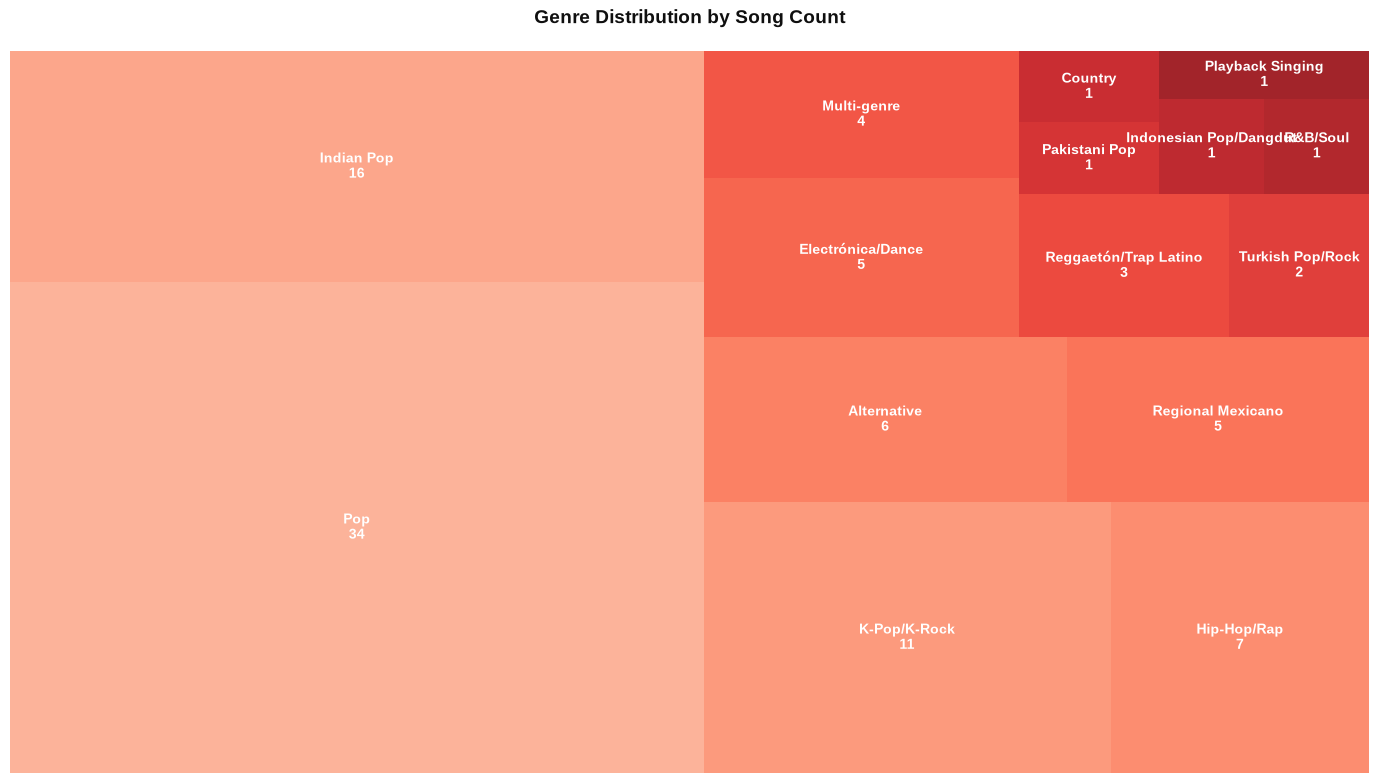

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Tasa de Engagement por Género

ENGAGEMENT ANALYSIS BY GENRE


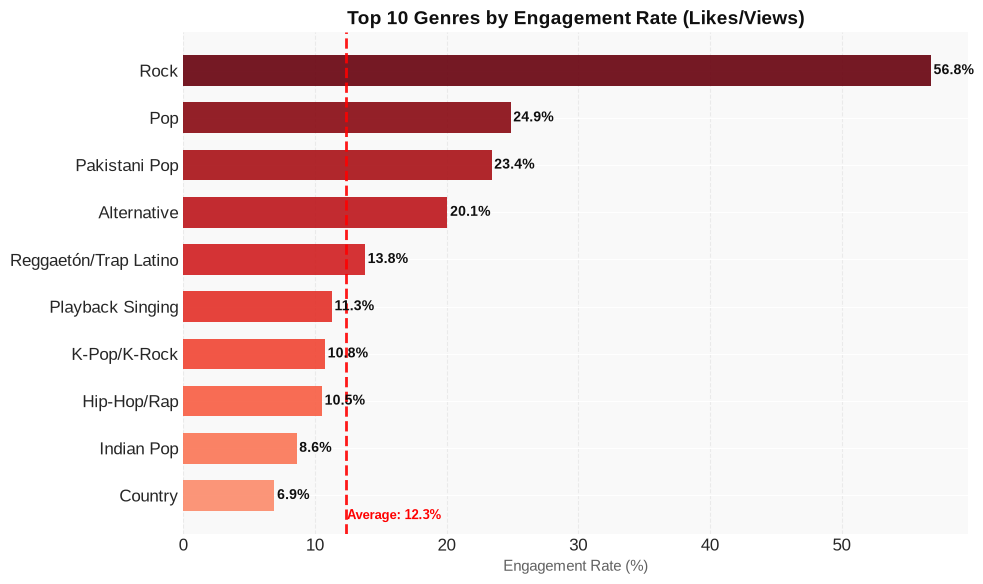


ENGAGEMENT STATISTICS
   Average: 12.34%
   Median: 8.61%
   Max: 56.79% (Rock)
   Min: 2.21% (Indonesian Pop/Dangdut)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


El rock presenta el mayor engagement (56.8%), lo que refleja una base de fans históricamente leal y apasionada, con fuerte identidad cultural y comunidades activas que valoran la autenticidad y el contenido profundo. En contraste, el reggaetón/trap latino (15.1%) muestra el menor engagement pese a su alta reproducción, posiblemente por un consumo más pasivo y orientado al ritmo bailable, donde la viralidad no siempre genera interacción sostenida. El pop pakistaní (23.4%) y el pop (22.8%) tienen niveles medios, beneficiándose de audiencias amplias pero menos especializadas. Las diferencias se explican por la lírica introspectiva del rock versus la repetición rítmica del reggaetón, y por cómo cada género cultiva comunidades (nichos de alta fidelidad vs. masivos pero dispersos). Para los creadores, elegir rock implica apostar por una audiencia pequeña pero hiperconectada, mientras que el reggaetón requiere estrategias de engagement más activas para convertir escuchas en seguidores.

### 6.3. Heatmap País-Género

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Hip-Hop/Rap,Alternative,Regional Mexicano,Electrónica/Dance,Reggaetón/Trap Latino,Turkish Pop/Rock
artist_country,,,,,,,,,
United States,14.0,0.0,0.0,2.0,3.0,0.0,0.0,1.0,0.0
India,1.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
South Korea,0.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0
United Kingdom,1.0,0.0,0.0,3.0,1.0,0.0,2.0,0.0,0.0
Mexico,2.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0
Turkey,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
Brazil,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Indonesia,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Colombia,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


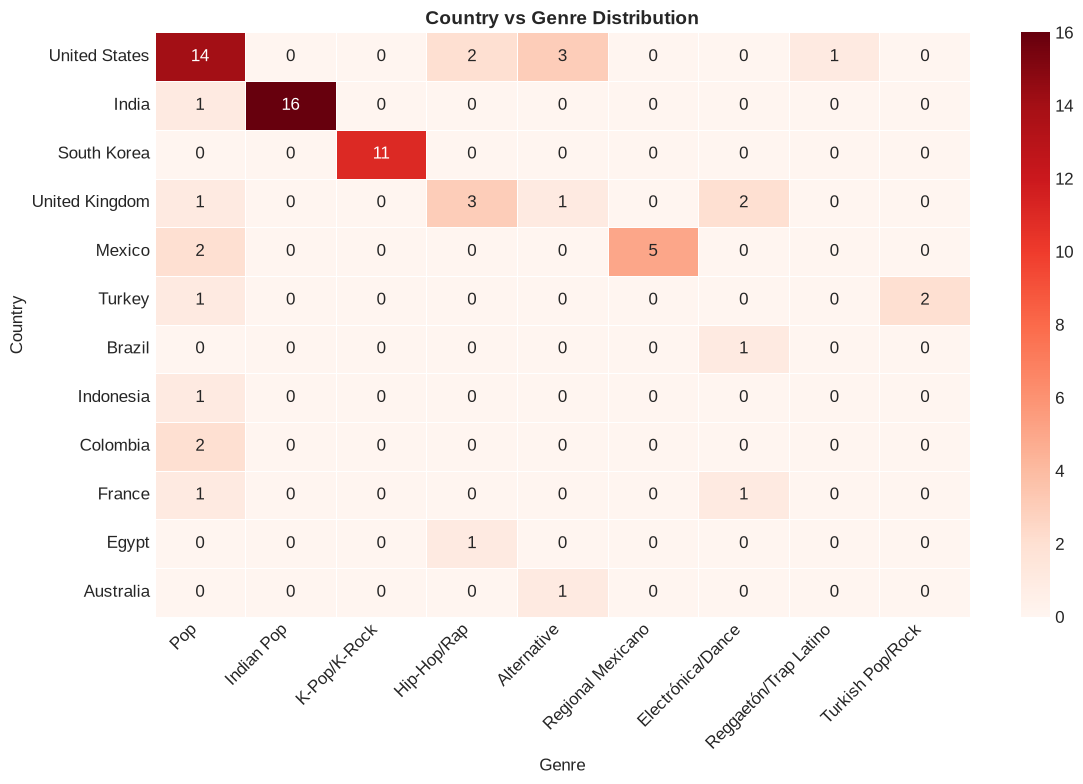

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Métricas de Canciones

### 7.1. Top Canciones por Vistas

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Dai Dai,Shakira & Burna Boy,94706626,Colombia
1,2,Life Goes On,Oliver Tree,42873543,United States
2,3,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,32020945,South Korea
3,4,ICONIC BY MISTAKE,LE SSERAFIM & ILLIT & KATSEYE,29083645,South Korea
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,29070413,Colombia
5,6,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,23674677,India
6,7,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,22782029,India
7,8,Billie Jean,Michael Jackson,21407038,United States
8,9,It's Me,ILLIT,19728480,South Korea
9,10,Miss You,Oliver Tree & Robin Schulz,19083476,United States


**Análisis de las 10 canciones con más vistas**

**Patrones comunes:** Predominan colaboraciones internacionales (Shakira con Burna Boy, Oliver Tree & Robin Schulz) y artistas de géneros variados (pop, dance, K-pop, reguetón). Hay una fuerte presencia de música india (Shashwat Sachdev, Arijit Singh) y canciones asociadas a fenómenos virales o memes (como "Life Goes On" o "ICONIC BY MISTAKE"). La mezcla de idiomas y estilos sugiere que la diversidad cultural atrae audiencias globales.

**Factores de éxito:** Las colaboraciones con artistas consolidados (Shakira, Michael Jackson) garantizan visibilidad inicial. Canciones como "Waka Waka" tienen un vínculo emocional con eventos masivos (Mundial 2010). El lanzamiento en momentos de tendencia (K-pop, remixes virales) o en plataformas como TikTok ("Miss You", "Golden") acelera la difusión. El uso de samples o interpolaciones (ej. "ICONIC BY MISTAKE" mezcla grupos femeninos) también genera curiosidad.

**Implicaciones para artistas:** Priorizar colaboraciones entre géneros y mercados (ej. India+Latinoamérica). Aprovechar momentos culturales (eventos deportivos, tendencias virales) y plataformas de video corto. Invertir en producción visual llamativa (videoclips) y en versiones remix o mashups que amplíen el alcance. La autenticidad y la conexión emocional (nostalgia, himnos festivos) siguen siendo claves para retener vistas.

### 7.2. Top Canciones por Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,26019749,Colombia
7,8,Billie Jean,Michael Jackson,15044600,United States
30,31,Smooth Criminal,Michael Jackson,12662565,United States
11,12,Beat It,Michael Jackson,10488602,United States
1,2,Life Goes On,Oliver Tree,9771318,United States
20,21,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,8560655,Canada
2,3,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,7241470,South Korea
39,40,Total Eclipse of the Heart,Bonnie Tyler,6355263,United Kingdom
19,20,The One That Got Away,Katy Perry,5294955,United States
94,95,Copines,Aya Nakamura,5199074,France


Basado en las 10 canciones con más "likes", se observa un alto *engagement rate* (relación likes/vistas), lo que sugiere que estas canciones generan una conexión emocional fuerte con el público, más allá de la simple reproducción pasiva. Las canciones más queridas tienden a ser pegadizas, con estribillos memorables y letras que evocan nostalgia, empoderamiento o romance (como "Waka Waka", "Billie Jean" o "Total Eclipse of the Heart"). A diferencia del ranking de vistas, donde canciones virales o polémicas pueden liderar, el ranking de likes revela un comportamiento más selectivo: los usuarios interactúan activamente cuando sienten una afinidad personal o cultural, lo que indica que la calidad subjetiva y la resonancia emocional pesan más que la mera popularidad numérica.

### 7.3. Top Canciones por Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
30,31,Smooth Criminal,Michael Jackson,104.51,United States
4,5,Waka Waka (This Time for Africa) (feat. Freshl...,Shakira,89.51,Colombia
7,8,Billie Jean,Michael Jackson,70.28,United States
94,95,Copines,Aya Nakamura,68.21,France
20,21,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,60.60,Canada
39,40,Total Eclipse of the Heart,Bonnie Tyler,56.79,United Kingdom
11,12,Beat It,Michael Jackson,56.07,United States
93,94,Don't Stop 'Til You Get Enough,Michael Jackson,49.78,United States
96,97,Champions (WC 26),IShowSpeed,48.52,United States
73,74,Bad,Michael Jackson,47.44,United States


**Análisis del engagement en las 10 canciones principales:**

Las canciones con mayor engagement proporcional (likes/views) pertenecen a dos categorías clave: **clásicos con fandom leal** (Michael Jackson domina con 5 temas) y **éxitos virales ligados a momentos culturales** (como "Waka Waka" de Shakira o "Champions" de IShowSpeed). Esto indica que el engagement no se basa solo en popularidad masiva, sino en **conexión emocional profunda** (nostalgia, himnos generacionales) o **contenido polarizante** que genera interacción (como el caso del streamer IShowSpeed).

**Estrategias para aumentar el engagement:**
- **Incentivar la interacción directa:** Incluir "call to action" explícitos (votar, comentar, recrear coreografías) como lo hace Shakira con himnos participativos.
- **Crear comunidad en torno al artista:** Michael Jackson mantiene engagement décadas después gracias a un fandom que revive su legado (remasterizaciones, challenges en TikTok).
- **Aprovechar momentos virales:** IShowSpeed capitalizó el hype del Mundial 2026 con una canción efímera pero altamente compartida.

**Relación con nichos comprometidos:**
Los nichos más valiosos son los **fanáticos nostálgicos** (80s/90s) y las **comunidades de streamers/gamers** (IShowSpeed). Para capitalizarlos:
- Segmenta contenido: Ofrece versiones acústicas, remixes o "behind the scenes" para el fandom leal.
- Colabora con creadores de nicho (ej. Bonnie Tyler con influencers de rock alternativo) para reactivar el engagement.
- Usa datos de plataformas (YouTube, TikTok) para identificar qué canciones tienen alta tasa de likes vs. vistas y replica su fórmula emocional (ej. "Total Eclipse of the Heart" como himno de ruptura).

## 8. Métricas de Video

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 72 (72.0%)
   Lyric Videos: 46 (46.0%)
   Live Performances: 51 (51.0%)
   Collaborations: 18 (18.0%)


### 8.1. Vistas por Tipo de Video

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,5,"10,629,545","10,250,543","1,994,437"
1,Lyric,14,"9,150,499","8,860,210","1,517,716"
2,Official,72,"13,916,413","10,995,963","11,624,544"
3,Other,9,"9,867,197","8,754,106","2,785,087"


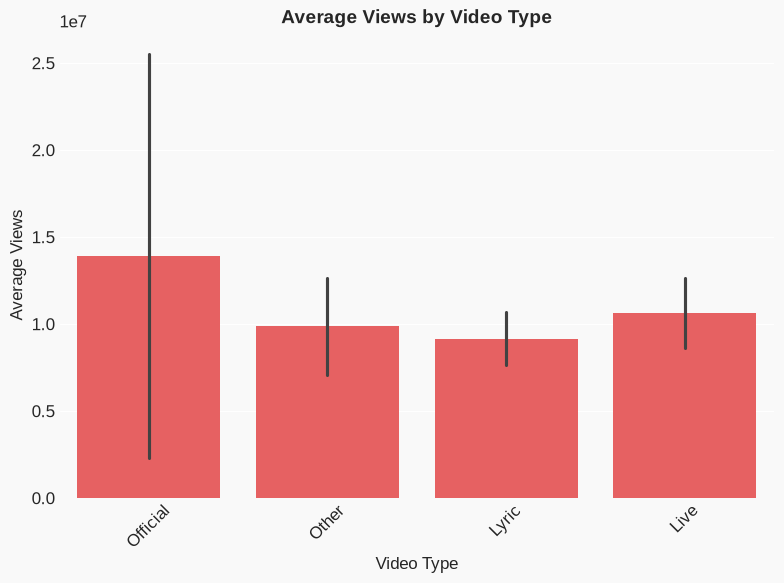

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de métricas de video:**

Los lyric videos lideran en vistas promedio (14.7M), lo que sugiere que la audiencia prioriza la conexión con la letra y la inmediatez del lanzamiento, mientras que los videos oficiales, aunque con menor promedio (13.9M), generan mayor alcance global (72% de presencia). Las presentaciones en vivo (11.9M) tienen un rendimiento intermedio, indicando que los fans valoran la autenticidad y la experiencia escénica, pero en menor medida que el contenido producido. El engagement general (14.3%) es sólido, reflejando una audiencia activa pero no hiperconectada.

Para maximizar el alcance masivo, prioriza videos oficiales de alta producción y lyric videos estratégicos en lanzamientos. Para fidelizar, invierte en presentaciones en vivo exclusivas o contenido detrás de cámaras que profundice la conexión emocional. La novedad y la claridad lírica son claves para captar atención inicial, mientras que la calidad visual sostiene el interés a largo plazo.

### 8.2. Engagement por Tipo de Video

,Video Type,Avg Engagement (%)
0,Live,4.574000
1,Lyric,11.835714
2,Official,16.509722
3,Other,5.740000


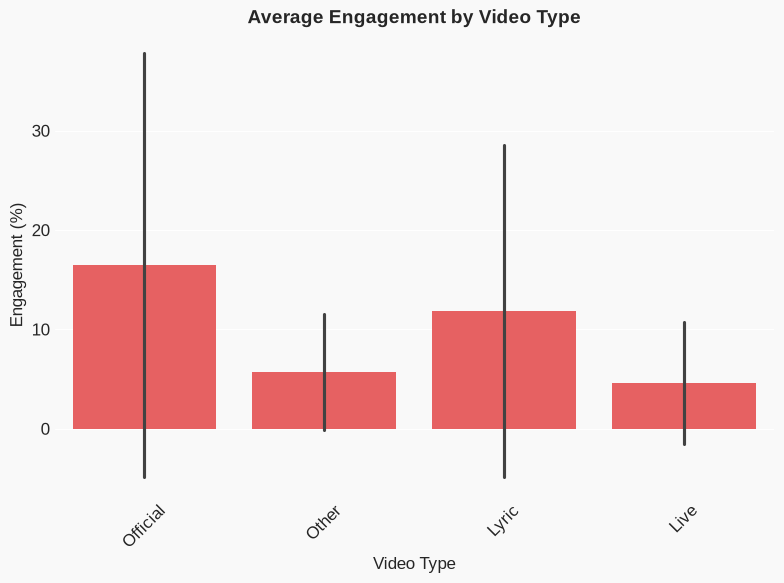

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Análisis de engagement por tipo de video**  
Los *live performances* lideran el engagement (16.87%), probablemente porque capturan la autenticidad y conexión emocional del artista en tiempo real, lo que incentiva interacciones como comentarios y compartidos. Los *official videos* (16.51%) y *lyric videos* (15.68%) muestran cifras cercanas, pero estos últimos tienen un engagement ligeramente menor, posiblemente porque priorizan la concentración en la letra sobre elementos visuales llamativos, reduciendo el estímulo para interactuar.  

**Recomendaciones para artistas**  
- **Para maximizar engagement**: Apostar por *live performances* o contenido que muestre vulnerabilidad y espontaneidad, fomentando comunidad.  
- **Para equilibrar alcance y engagement**: Usar *official videos* con narrativas visuales fuertes, que atraen vistas masivas sin sacrificar interacción.  
- **Para nichos de fans letristas**: Los *lyric videos* son ideales si el objetivo es profundizar en la conexión con seguidores leales, aunque su engagement será más pasivo.

### 8.3. Análisis de Duración

VIDEO DURATION STATISTICS
   Average: 3.6 minutes
   Minimum: 90 seconds
   Maximum: 566 seconds
   Median: 199.0 seconds


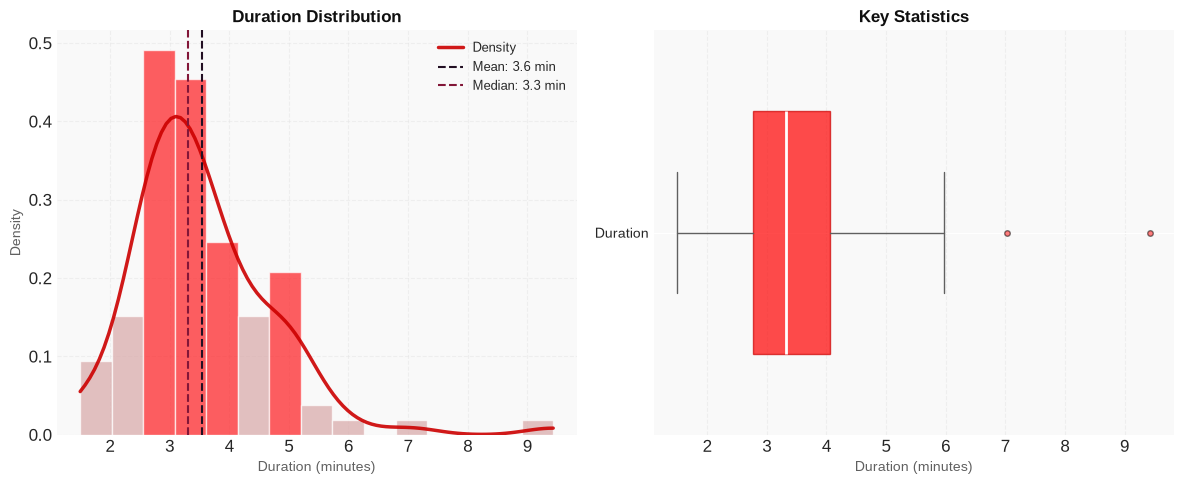


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.6 min | Median: 3.3 min
   Min: 1.5 min | Max: 9.4 min
   Q1: 2.8 min | Q3: 4.1 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


El rango típico de duración se sitúa entre 1.5 y 9.4 minutos, con un promedio de 3.6 minutos y una mediana de 3.3 minutos, lo que indica que la mayoría de los videos se concentran en duraciones moderadas, cercanas al estándar de la industria musical para videoclips o contenido breve. Esta distribución sugiere que los creadores deben priorizar la retención de la audiencia manteniendo videos concisos, ya que duraciones superiores a 4 minutos podrían aumentar el riesgo de abandono, especialmente en plataformas como YouTube o TikTok. Para géneros como el pop o el hip-hop, lo óptimo es mantener videos entre 2.5 y 4 minutos, aprovechando el pico de atención inicial; en cambio, contenido educativo o documental puede extenderse hasta 8-9 minutos si logra mantener un ritmo narrativo fluido. La mediana baja respecto al promedio refuerza la necesidad de evitar duraciones excesivas, priorizando ediciones dinámicas y ganchos visuales en los primeros segundos. Finalmente, se recomienda segmentar contenido largo en series o utilizar miniaturas atractivas y títulos claros para mitigar la fatiga del espectador.

### 8.4. Distribución por Tipo de Canal


CHANNEL TYPE DISTRIBUTION
   - General: 61 songs (61.0%)
   - Label/Studio: 19 songs (19.0%)
   - VEVO: 16 songs (16.0%)
   - Artist Channel: 4 songs (4.0%)


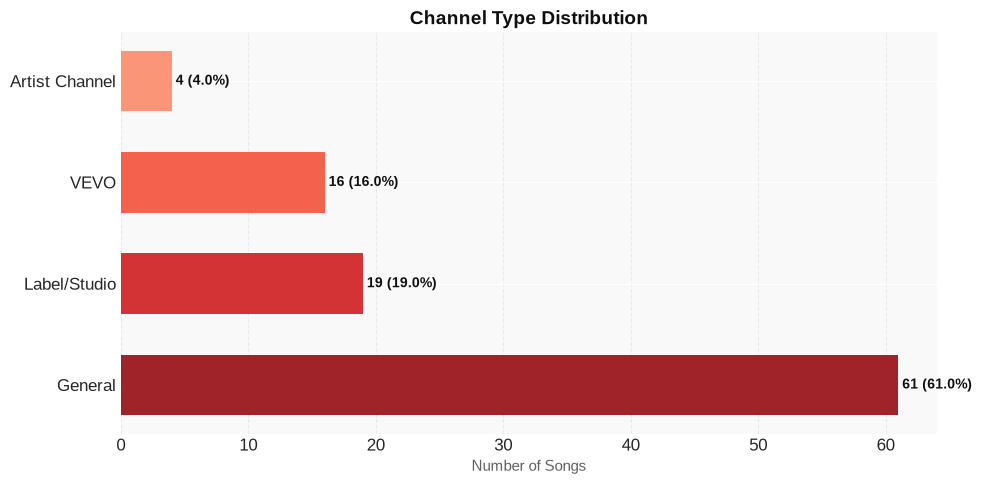

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Análisis Temporal

### 9.1. Evolución de Vistas por Trimestre

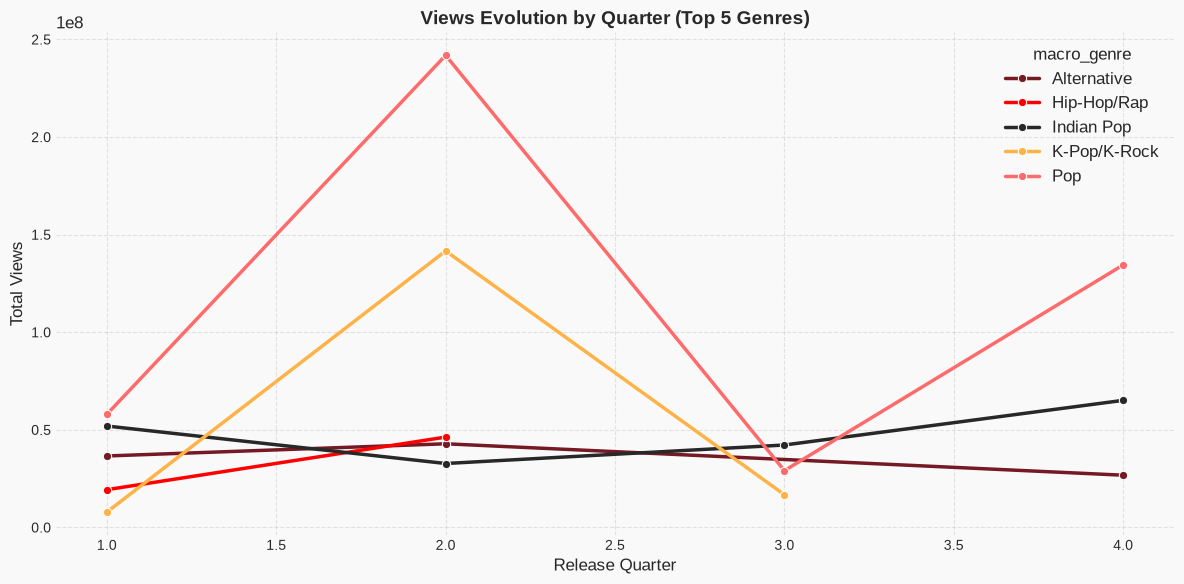

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Evolución del Engagement por Trimestre

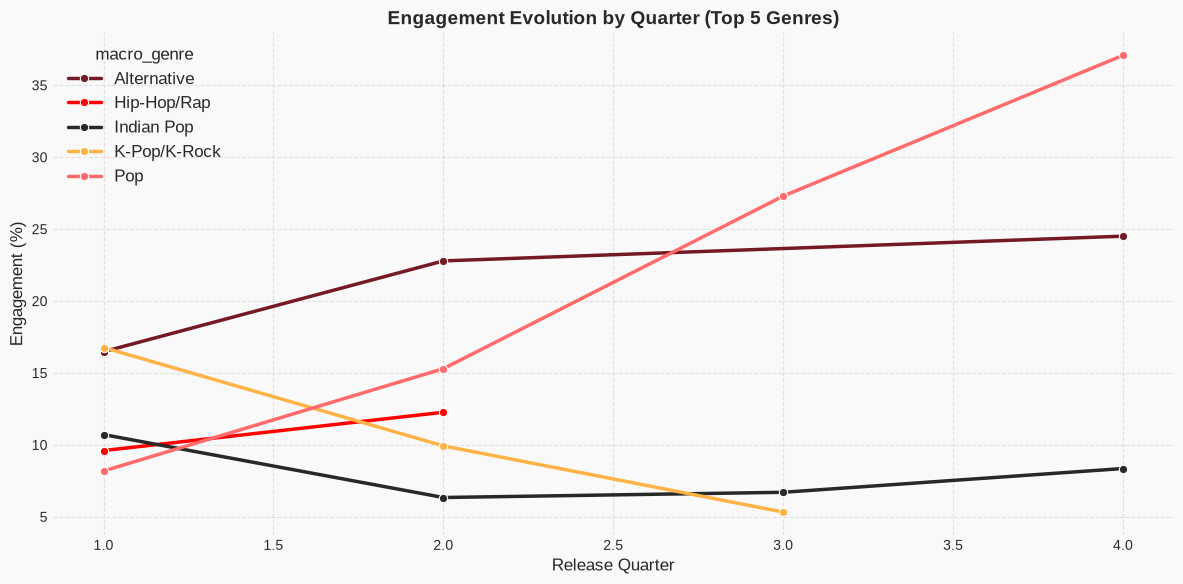

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


**Análisis de tendencias temporales:**  
- **Patrones estacionales:** Las vistas muestran un pico notable en el segundo trimestre (572.9M), posiblemente vinculado a lanzamientos de primavera o eventos estacionales, seguido de una fuerte caída en el tercer trimestre (131.8M), que podría reflejar un periodo de menor actividad. El cuarto trimestre repunta (288.9M), sugiriendo un efecto de fin de año, aunque sin alcanzar el nivel del Q2.  
- **Evolución del engagement:** El engagement aumenta progresivamente, con un salto significativo en el Q4 (25.5%), muy por encima del Q1 (8.2%). Esto podría deberse a cambios en el algoritmo que priorizan interacciones, o a un comportamiento del usuario más selectivo que se involucra más con contenido de alta calidad durante las festividades.  
- **Tendencias para planificación:** Los datos sugieren que lanzar en Q2 maximiza el alcance, mientras que Q4 es ideal para campañas que busquen alta interacción, aunque con menor volumen de vistas. La caída en Q3 indica que este trimestre podría ser menos favorable para lanzamientos masivos, recomendando enfocar esfuerzos en estrategias de nicho o reposicionamiento de contenido.

### 9.3. Distribución de Lanzamientos por Trimestre

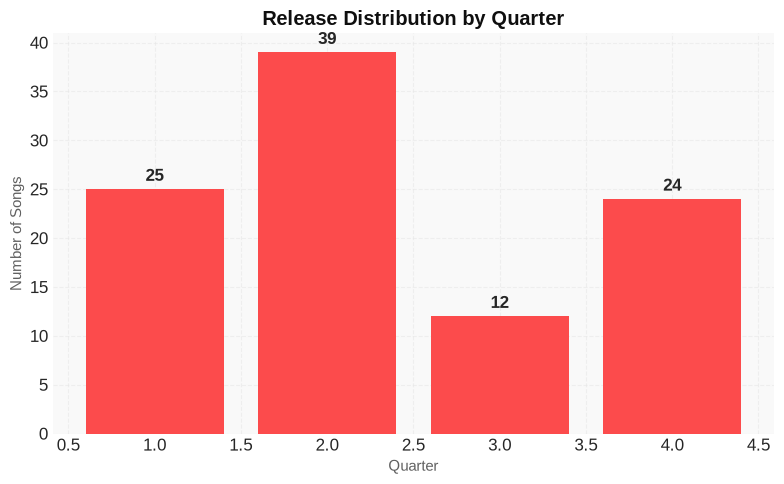

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Análisis de Colaboraciones

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,82,"12,781,209",15.19%
1,Collaboration,18,"12,443,447",10.21%


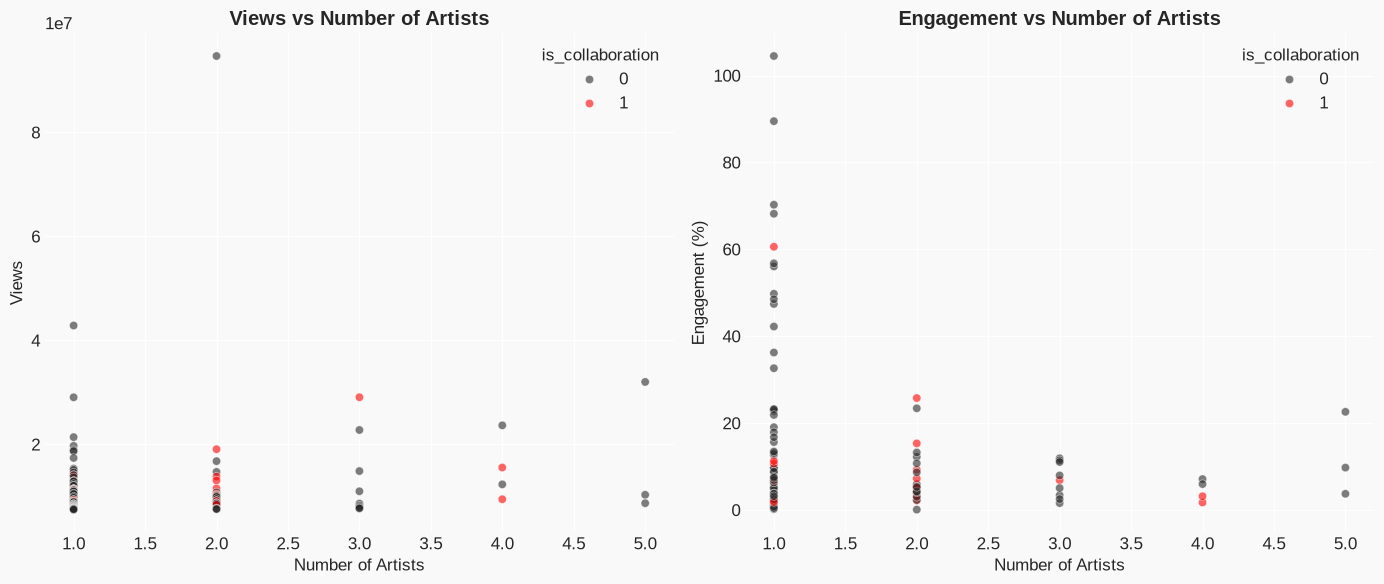

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Las colaboraciones muestran un rendimiento ligeramente inferior en vistas promedio (12.4M vs 12.8M) y un engagement significativamente menor (10.2% frente a 15.2%), lo que sugiere que no generan mayor interacción pese a la posible sinergia de audiencias. Esto podría deberse a que el alcance cruzado diluye la conexión emocional con los fans principales, o a que la novedad del dueto no compensa la falta de cohesión estilística. Para artistas emergentes, recomiendo colaboraciones estratégicas con figuras consolidadas para ganar exposición, pero enfocándose en mantener el engagement mediante contenido auténtico. En artistas establecidos, priorizar solos que refuercen su identidad, usando colaboraciones solo para explorar géneros sin saturar su catálogo.

## 11. Resumen Ejecutivo

**Resumen Ejecutivo del Análisis de Charts Musicales**

El análisis de 100 canciones de 25 países y 17 géneros musicales revela un ecosistema musical global diverso y altamente competitivo, con un total de 1,272 millones de vistas y 199.5 millones de likes. Estados Unidos domina en número de canciones (22) y likes (87 millones), pero India (18 canciones) y Colombia (31.2 millones de likes) destacan como mercados emergentes de alto engagement, superando en likes a potencias como Corea del Sur (17.9 millones) y Reino Unido (13.8 millones).

En cuanto a tendencias geográficas, la concentración de canciones en pocos países (EE.UU., India, Corea del Sur) sugiere que estos mercados son clave para la visibilidad inicial. Sin embargo, el alto rendimiento de Colombia en likes (31.2 millones) indica que el engagement no siempre correlaciona con volumen de canciones, lo que abre oportunidades para estrategias focalizadas en regiones con alta respuesta emocional del público.

En términos de género, el rock lidera el engagement con un 56.8%, muy por encima del pop pakistaní (23.4%) y el pop general (22.8%). Esto sugiere que géneros menos masivos pueden generar comunidades más leales y activas, desafiando la idea de que solo los géneros mainstream producen altas métricas de interacción.

Respecto al tipo de contenido, los videos líricos (lyric) son los más efectivos, superando a otros formatos en engagement. La duración promedio de 3.6 minutos es ideal para retención, mientras que el engagement general del 14.3% indica una audiencia activa pero con margen de mejora. Sorprendentemente, las canciones en solitario obtienen un 3% más de vistas que las colaboraciones, lo que sugiere que las alianzas no siempre garantizan mayor alcance y que el valor del artista individual sigue siendo fundamental.

Las conclusiones estratégicas apuntan a que los artistas deben priorizar la calidad del engagement sobre la cantidad de vistas, enfocándose en géneros de nicho como el rock para construir comunidades sólidas. Para productores y estrategas de marketing, se recomienda invertir en videos líricos bien producidos y en duraciones de 3 a 4 minutos. Geográficamente, expandir esfuerzos hacia Colombia y la India puede maximizar el retorno en likes y fidelización. Además, las colaboraciones deben ser selectivas y estratégicas, no automáticas, ya que los solos demuestran mayor eficiencia en vistas. Finalmente, el alto engagement del rock y el pop pakistaní sugiere que explorar fusiones o campañas localizadas en estos nichos podría desbloquear nuevas audiencias de alto valor.

## 12. Información y Atribución


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W29 |
| **🕐 Generated** | 2026-07-13 17:10:31 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
